In [1]:
import pandas as pd

data = pd.read_excel('../../../data/raw/data_battery_materials_PRISTINE_CORRECTED_15.09.xlsx')
data_substrate = data[['smiles (substrate)', 'capacitance_max']]
data_substrate = data_substrate.rename(columns={'smiles (substrate)': 'smiles', 'capacitance_max': 'capacity_max'})
data_substrate

,smiles,capacity_max
0,N#CC1=CC=C(C#N)C=C1,628.0
1,CC(C1=CC=C(N2C3=C(C=C2C4=CC=C(C=C4)C#N)N(C5=CC...,255.0
2,CC1=CC2=C(N=C(S2)N3C(C4=CC=C(C=C4)C#N)=CC5=C3C...,269.0
3,ClC1=NC(C2=CC=C(C3=CC(C4=CC=C(C5=NC(Cl)=NC(Cl)...,228.0
4,ClC1=NC(Cl)=NC(NC2=CC3=C(C=C2)C(C4=C(C3=O)C=CC...,468.0
...,...,...
116,NC(C=C1)=CC=C1C2=NC(C3=CC=C(N)C=C3)=NC(C4=CC=C...,640.0
117,NC(C=C1)=CC=C1C2=NC(C3=CC=C(/N=C/C4=CC(C(C(SC(...,273.0
118,N#CC(C=C1)=CC=C1C2=C(C3=CC=C(C#N)C=C3)S/C(S2)=...,943.0
119,CC1=CC(C2=NC(C3=CC(C)=C(N)C(C)=C3)=NC(C4=CC(C)...,33.0


In [4]:
#valid smiles
from rdkit import Chem
def is_valid_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False
data_substrate = data_substrate[data_substrate['smiles'].apply(is_valid_smiles)]

#canon smiles
def canon_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True)

print(len(data_substrate))
data_substrate['smiles'] = data_substrate['smiles'].apply(canon_smiles)
print(len(data_substrate))

120
120


In [6]:
data_substrate.drop_duplicates(inplace=True)
print(len(data_substrate))

119


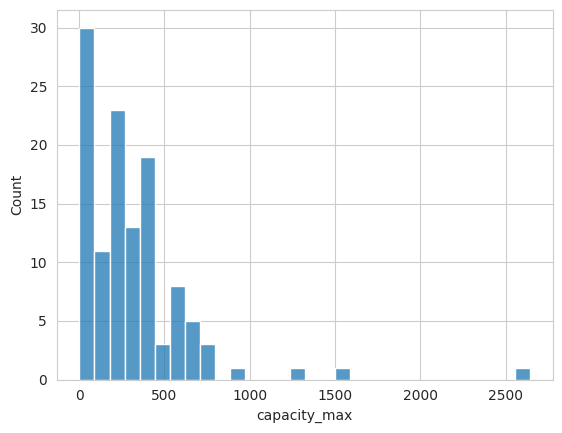

In [7]:
#remove outliers
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data_substrate['capacity_max'], bins=30)
plt.show()

116


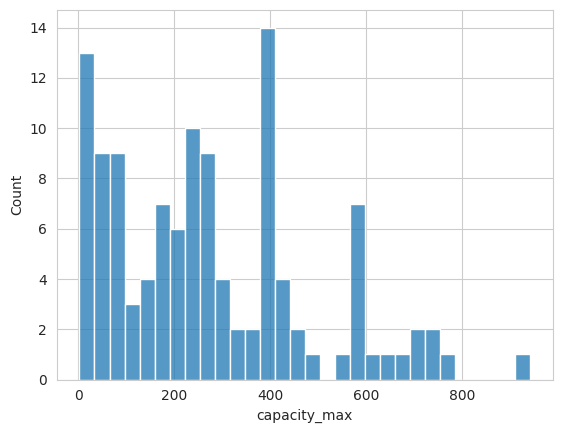

In [11]:
df_substrate = data_substrate[data_substrate['capacity_max'] < 1000]
print(len(df_substrate))
sns.histplot(df_substrate['capacity_max'], bins=30)
plt.show()

In [12]:
#all
import os
os.makedirs('../../../data/predictor/cof', exist_ok=True)
df_substrate.to_csv('../../../data/predictor/cof/data_substrate_cofs.csv', index=False)

In [13]:
#ctfs

def extract_ctfs(smiles_string):
    """
    Checks for the presence of a nitrile group (-CN) in a molecule
    represented by a SMILES string.

    Args:
    smiles_string: The SMILES string of the molecule.

    Returns:
    A tuple containing a boolean indicating if the group was found,
    and the atom indices of the matches.
    """
    mol = Chem.MolFromSmiles(smiles_string)
    if mol is None:
        print("Invalid SMILES string.")
        return False, []
    nitrile_smarts = "[C]#[N]"
    nitrile_pattern = Chem.MolFromSmarts(nitrile_smarts)
    has_nitrile = mol.HasSubstructMatch(nitrile_pattern)
    return has_nitrile

df_ctfs = df_substrate[df_substrate['smiles'].apply(extract_ctfs)]
print(len(df_ctfs))
df_ctfs

30


,smiles,capacity_max
0,N#Cc1ccc(C#N)cc1,628.0
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C...,269.0
6,N#Cc1c(F)c(F)c(C#N)c(F)c1F,379.0
7,N#CC(C#N)=c1ccc(=C(C#N)C#N)cc1,383.0
8,N#C/C=C/C#N,404.0
9,N#Cc1ccc(-c2cc3c(cc(-c4ccc(C#N)cc4)n3-c3ccc(C#...,291.0
10,N#Cc1cc(C#N)c2ccc3c(C#N)cc(C#N)c4ccc1c2c43,500.0
11,N#Cc1c2ccccc2c(C#N)c2ccccc12,589.0
12,N#Cc1cncc(C#N)c1,66.0


In [14]:
os.makedirs('../../../data/predictor/ctf', exist_ok=True)
df_ctfs.to_csv('../../../data/predictor/ctf/data_substrate_ctfs.csv', index=False)